In [52]:
import pandas as pd
df = pd.read_csv("sales_satisfaction.csv")
df.head()


,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made
0,Control,High Value,240.548359,300.007568,74.684767,NaN,No
1,Treatment,High Value,246.862114,381.337555,100.000000,100.000000,Yes
2,Control,High Value,156.978084,179.330464,98.780735,100.000000,No
3,Control,Medium Value,192.126708,229.278031,49.333766,39.811841,Yes
4,NaN,High Value,229.685623,NaN,83.974852,87.738591,Yes


In [53]:
def classify_columns(dataframe):
    column_info = {}
    for column in dataframe.columns:
        # Check data type
        dtype = dataframe[column].dtype
        # Classify column
        if pd.api.types.is_numeric_dtype(dataframe[column]):
            column_type = 'Numerical'
        elif pd.api.types.is_categorical_dtype(dataframe[column]) or dataframe[column].nunique() < 20:
            column_type = 'Categorical'
        else:
            column_type = 'Other'
        column_info[column] = column_type
    
    
    print("Column Classification:")
    for col, col_type in column_info.items():
        print(f"{col}: {col_type}")

classify_columns(df)

Column Classification:
Group: Categorical
Customer_Segment: Categorical
Sales_Before: Numerical
Sales_After: Numerical
Customer_Satisfaction_Before: Numerical
Customer_Satisfaction_After: Numerical
Purchase_Made: Categorical


C:\Users\Takia Sadaf\AppData\Local\Temp\ipykernel_10716\2460339999.py:9: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dataframe[column]) or dataframe[column].nunique() < 20:



Analysis for Column: Group
           Frequency  Percentage (%)
Group                               
Control         4300       50.005815
Treatment       4299       49.994185
----------------------------------------


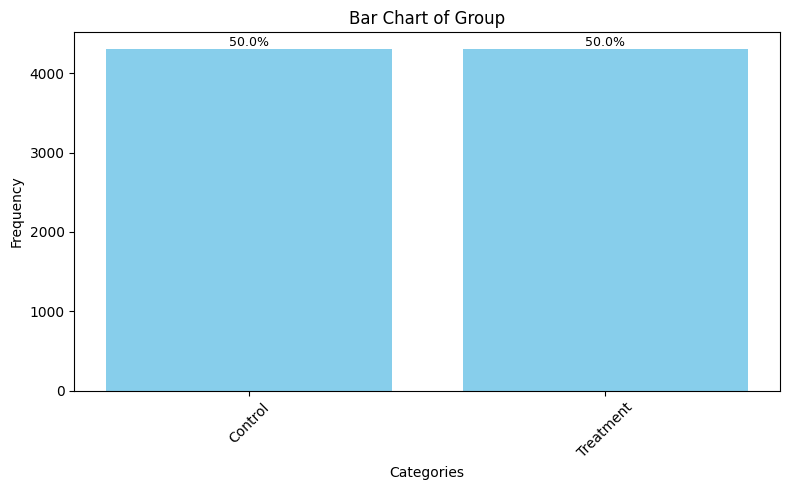


Analysis for Column: Customer_Segment
                  Frequency  Percentage (%)
Customer_Segment                           
Low Value              2699       33.594722
Medium Value           2697       33.569828
High Value             2638       32.835449
----------------------------------------


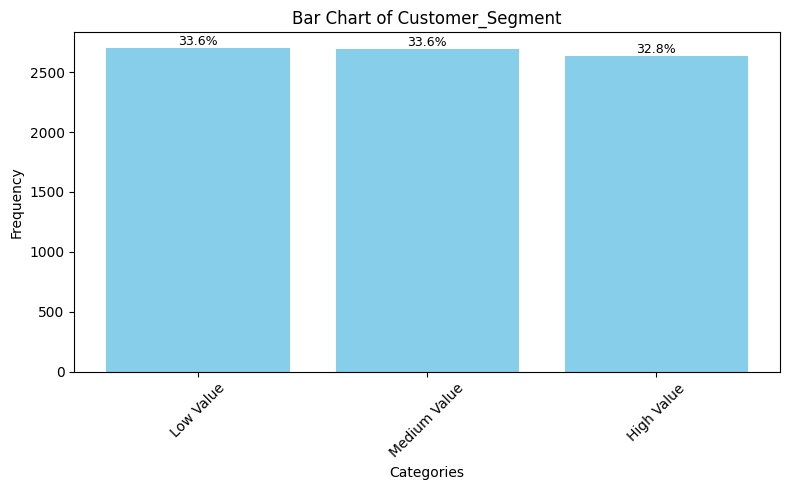


Analysis for Column: Purchase_Made
               Frequency  Percentage (%)
Purchase_Made                           
Yes                 4667       50.755846
No                  4528       49.244154
----------------------------------------


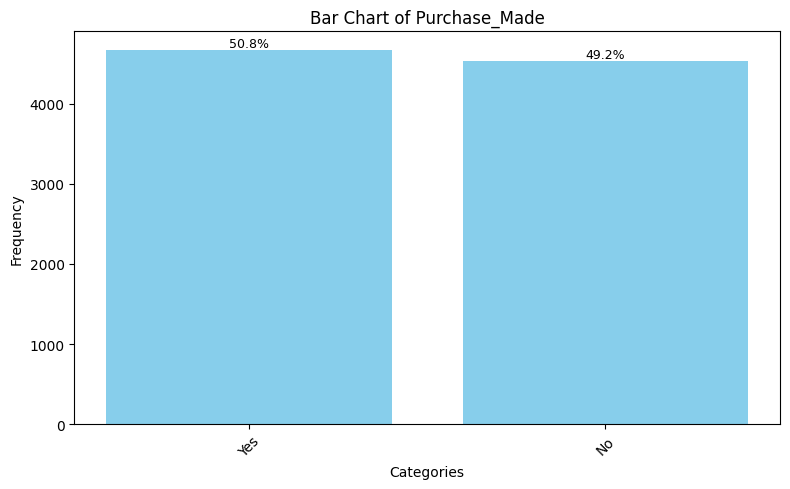

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: Adjust the function to your specific dataset
def analyze_categorical_columns_with_bar(dataframe):
    # Loop over all columns and focus on categorical ones
    for column in dataframe.columns:
        if dataframe[column].dtype == 'object' or dataframe[column].nunique() < 20:
            print(f"\nAnalysis for Column: {column}")
            
            frequency = dataframe[column].value_counts()
            percentage = dataframe[column].value_counts(normalize=True) * 100
            result = pd.DataFrame({
                'Frequency': frequency,
                'Percentage (%)': percentage
            })
            print(result)
            print("-" * 40)
            
            # Create the bar chart
            plt.figure(figsize=(8, 5))
            bars = plt.bar(frequency.index.astype(str), frequency.values, color='skyblue')
            plt.title(f"Bar Chart of {column}")
            plt.xlabel("Categories")
            plt.ylabel("Frequency")
            plt.xticks(rotation=45)
            
            # Add percentage labels on top of the bars
            for bar, pct in zip(bars, percentage):
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

            plt.tight_layout()
            plt.show()

# Load your dataset
df = pd.read_csv("sales_satisfaction.csv")  # replace with your actual file path

# Call the function to analyze categorical columns
analyze_categorical_columns_with_bar(df)


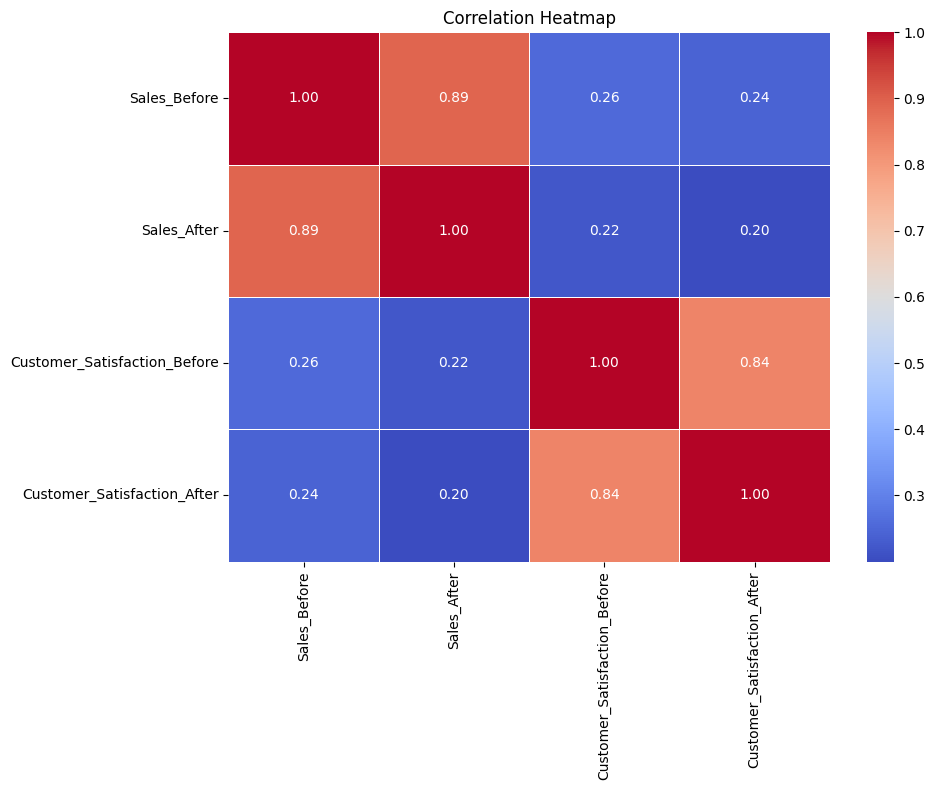

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("sales_satisfaction.csv")  # Replace with your file path

# Select only the numerical columns (excluding non-numeric columns)
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Compute the correlation matrix
correlation_matrix = df[numerical_columns].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)

# Title and labels
plt.title("Correlation Heatmap")
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()


In [18]:
# Check for missing values in the dataset
missing_values = df.isnull().sum()
print(missing_values)



Group                           1401
Customer_Segment                1966
Sales_Before                    1522
Sales_After                      767
Customer_Satisfaction_Before    1670
Customer_Satisfaction_After     1640
Purchase_Made                    805
dtype: int64


📊 Summary Statistics for Numerical Columns:

🔹 Column: Sales_Before
   Mean: 203.72
   Median: 203.32
   Variance: 3055.11
   Standard Deviation: 55.27
--------------------------------------------------
🔹 Column: Sales_After
   Mean: 280.46
   Median: 273.13
   Variance: 7337.56
   Standard Deviation: 85.66
--------------------------------------------------
🔹 Column: Customer_Satisfaction_Before
   Mean: 70.25
   Median: 69.49
   Variance: 287.54
   Standard Deviation: 16.96
--------------------------------------------------
🔹 Column: Customer_Satisfaction_After
   Mean: 73.87
   Median: 73.84
   Variance: 328.64
   Standard Deviation: 18.13
--------------------------------------------------


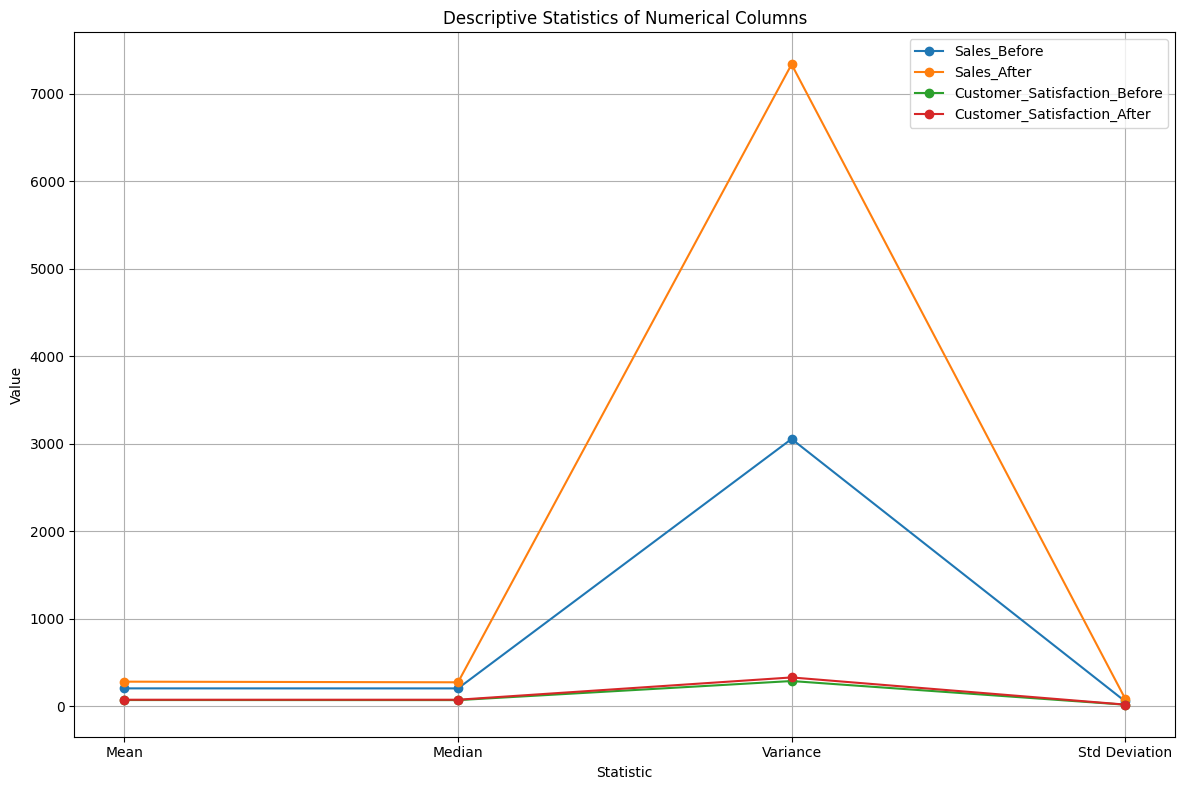

In [60]:
def analyze_and_plot_numerical_columns(dataframe):
    print("📊 Summary Statistics for Numerical Columns:\n")
    
    # Set up the figure size
    plt.figure(figsize=(12, 8))

    # Loop through each column in the DataFrame
    for column in dataframe.columns:
        # Check if the column contains numerical data
        if pd.api.types.is_numeric_dtype(dataframe[column]):
            # Compute statistical measures
            mean = dataframe[column].mean()
            median = dataframe[column].median()
            variance = dataframe[column].var()
            std_dev = dataframe[column].std()
            
            # Print the statistics
            print(f"🔹 Column: {column}")
            print(f"   Mean: {mean:.2f}")
            print(f"   Median: {median:.2f}")
            print(f"   Variance: {variance:.2f}")
            print(f"   Standard Deviation: {std_dev:.2f}")
            print("-" * 50)
            
            # Plotting the statistics
            stats_values = [mean, median, variance, std_dev]
            plt.plot([1, 2, 3, 4], stats_values, marker='o', label=column)

    # Customize the plot
    plt.title("Descriptive Statistics of Numerical Columns")
    plt.xlabel("Statistic")
    plt.ylabel("Value")
    plt.xticks([1, 2, 3, 4], ['Mean', 'Median', 'Variance', 'Std Deviation'])
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Run the function on your dataset
analyze_and_plot_numerical_columns(df)



📘 Analysis of Categorical Column: Group
           Frequency  Percentage (%)
Group                               
Control         4300           50.01
Treatment       4299           49.99
--------------------------------------------------


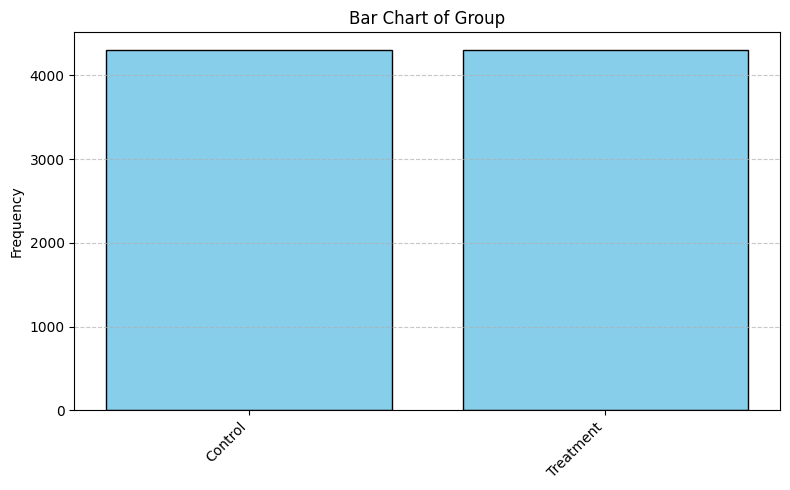


📘 Analysis of Categorical Column: Customer_Segment
                  Frequency  Percentage (%)
Customer_Segment                           
Low Value              2699           33.59
Medium Value           2697           33.57
High Value             2638           32.84
--------------------------------------------------


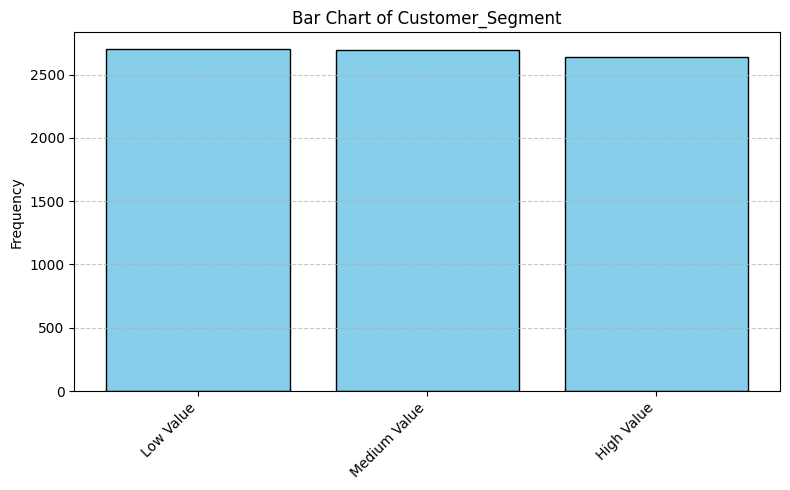


📘 Analysis of Categorical Column: Purchase_Made
               Frequency  Percentage (%)
Purchase_Made                           
Yes                 4667           50.76
No                  4528           49.24
--------------------------------------------------


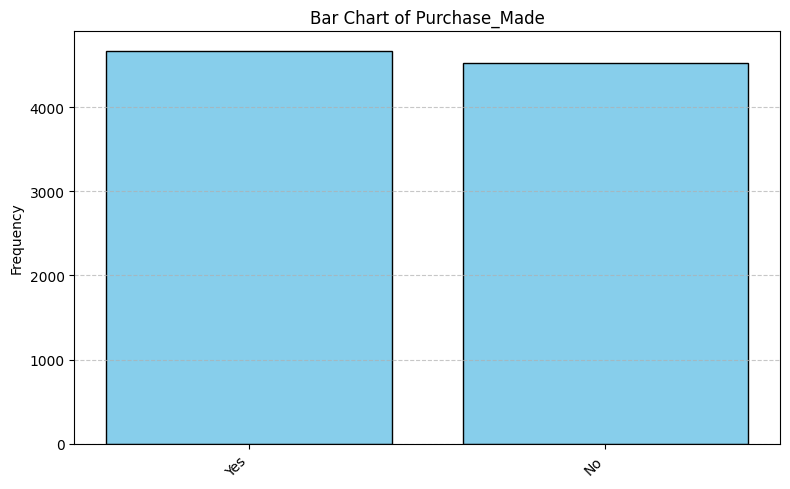

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_categorical_columns_with_barplots(dataframe):
    for column in dataframe.columns:
        # Check if column is categorical or has few unique values
        if dataframe[column].dtype == 'object' or dataframe[column].nunique() < 20:
            print(f"\n📘 Analysis of Categorical Column: {column}")

            # Calculate frequency and percentage
            freq = dataframe[column].value_counts()
            perc = dataframe[column].value_counts(normalize=True) * 100

            # Create a summary DataFrame
            summary = pd.DataFrame({
                'Frequency': freq,
                'Percentage (%)': perc.round(2)
            })
            print(summary)
            print("-" * 50)

            # Bar chart for frequency
            plt.figure(figsize=(8, 5))
            bars = plt.bar(freq.index, freq.values, color='skyblue', edgecolor='black')
            plt.title(f"Bar Chart of {column}")
            plt.ylabel("Frequency")
            plt.xticks(rotation=45, ha='right')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()

# Run the function
analyze_categorical_columns_with_barplots(df)




📘 Analysis of Categorical Column: Group
           Frequency  Percentage (%)
Group                               
Control         4300           50.01
Treatment       4299           49.99
--------------------------------------------------


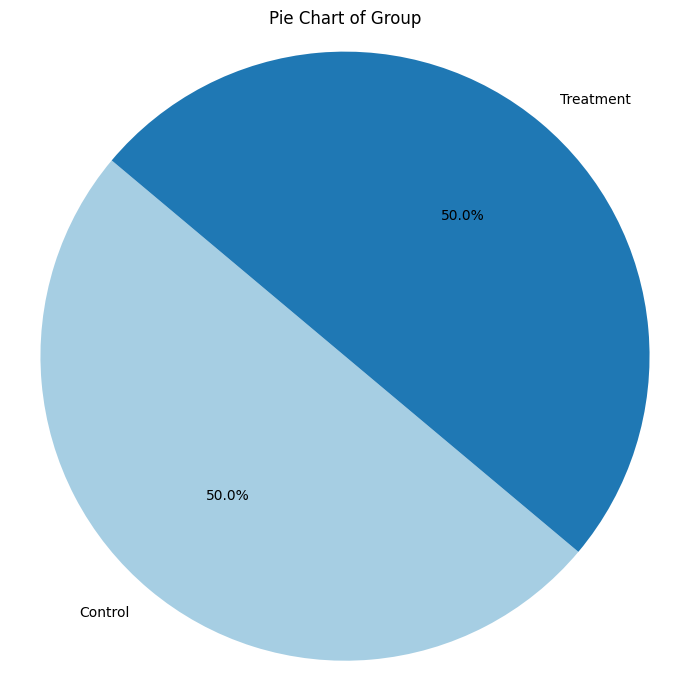


📘 Analysis of Categorical Column: Customer_Segment
                  Frequency  Percentage (%)
Customer_Segment                           
Low Value              2699           33.59
Medium Value           2697           33.57
High Value             2638           32.84
--------------------------------------------------


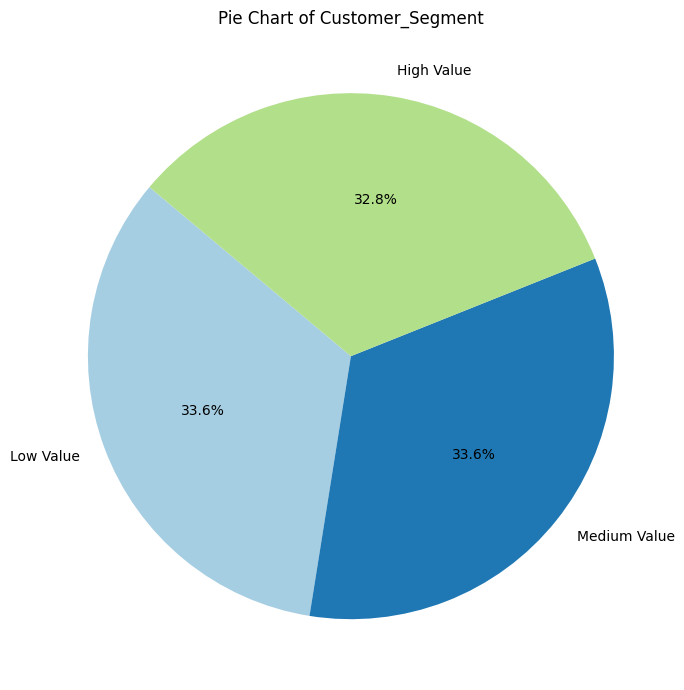


📘 Analysis of Categorical Column: Purchase_Made
               Frequency  Percentage (%)
Purchase_Made                           
Yes                 4667           50.76
No                  4528           49.24
--------------------------------------------------


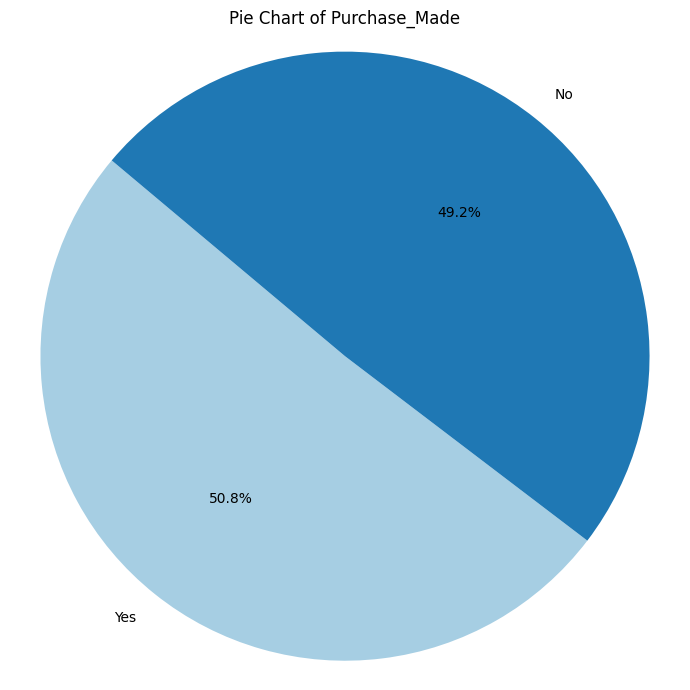

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_categorical_columns_with_piecharts(dataframe):
    for column in dataframe.columns:
        # Check if column is categorical or has few unique values
        if dataframe[column].dtype == 'object' or dataframe[column].nunique() < 20:
            print(f"\n📘 Analysis of Categorical Column: {column}")

            # Calculate frequency and percentage
            freq = dataframe[column].value_counts()
            perc = dataframe[column].value_counts(normalize=True) * 100

            # Create a summary DataFrame
            summary = pd.DataFrame({
                'Frequency': freq,
                'Percentage (%)': perc.round(2)
            })
            print(summary)
            print("-" * 50)

            # Pie chart for percentage
            plt.figure(figsize=(7, 7))
            plt.pie(freq.values, labels=freq.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
            plt.title(f"Pie Chart of {column}")
            plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular
            plt.tight_layout()
            plt.show()

# Run the function
analyze_categorical_columns_with_piecharts(df)


C:\Users\Takia Sadaf\AppData\Local\Temp\ipykernel_10716\3687303289.py:35: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Takia Sadaf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


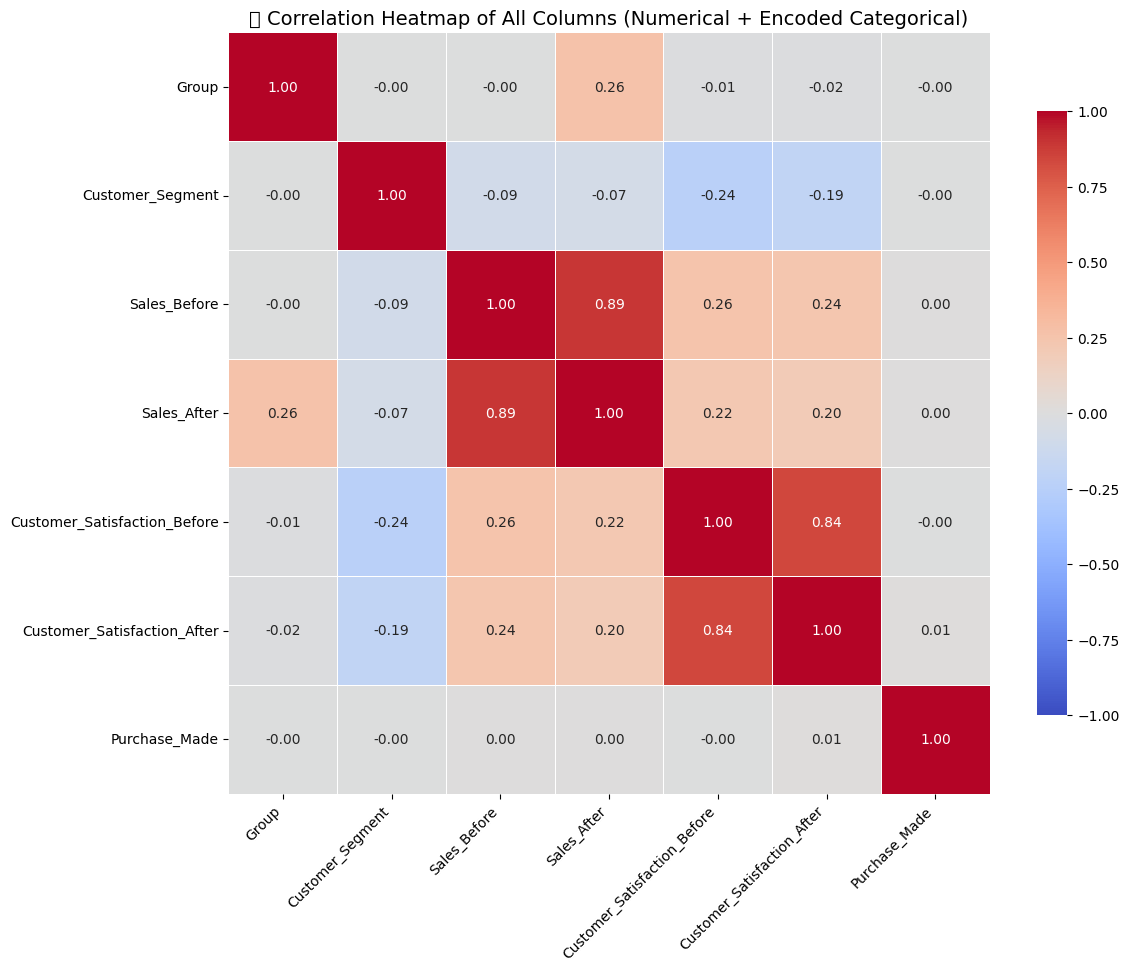

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

def encode_categorical_columns(dataframe):
    """
    This function encodes all categorical (object type) columns using Label Encoding.
    """
    le = LabelEncoder()
    categorical_columns = dataframe.select_dtypes(include=['object']).columns
    
    for column in categorical_columns:
        dataframe[column] = le.fit_transform(dataframe[column])
    
    return dataframe

# Encode the categorical columns
df_encoded = encode_categorical_columns(df.copy())

def plot_correlation_heatmap(dataframe):
    """
    This function creates and displays a correlation heatmap for all numerical and encoded columns.
    """
    corr_matrix = dataframe.corr()  # Calculate correlation matrix

    # Plot the heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,
                vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .75})

    plt.title("🔍 Correlation Heatmap of All Columns (Numerical + Encoded Categorical)", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Plot the heatmap
plot_correlation_heatmap(df_encoded)


In [70]:
from sklearn.preprocessing import LabelEncoder

# Sample categorical data
categories = ['Low', 'Medium', 'High']

# Initialize the encoder
encoder = LabelEncoder()

# Fit and transform the categories into numerical labels
encoded_labels = encoder.fit_transform(categories)

# Display the mapping of original categories to encoded labels
print("Original Categories:", categories)
print("Encoded Labels:", encoded_labels)

# Show the conversion count
print(f"Total categories converted: {len(categories)}")


Original Categories: ['Low', 'Medium', 'High']
Encoded Labels: [1 2 0]
Total categories converted: 3


In [72]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Original categorical data
categories = np.array(['Cat', 'Dog', 'Bird']).reshape(-1, 1)

# Initialize the encoder
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the data
one_hot_encoded = encoder.fit_transform(categories)

# Print results
print("Original Categories:\n", categories.flatten())
print("\nOne-Hot Encoded Output:\n", one_hot_encoded)

# Show mapping of category to one-hot vector
print("\nCategory to One-Hot Mapping:")
for category, vector in zip(categories.flatten(), one_hot_encoded):
    print(f"{category} → {vector}")

# Show total number of categories converted
print(f"\nTotal categories converted: {len(categories)}")


Original Categories:
 ['Cat' 'Dog' 'Bird']

One-Hot Encoded Output:
 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]

Category to One-Hot Mapping:
Cat → [0. 1. 0.]
Dog → [0. 0. 1.]
Bird → [1. 0. 0.]

Total categories converted: 3


In [55]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load your dataset
df = pd.read_csv("sales_satisfaction.csv")

# 1. Label Encoding (For binary columns like Gender)
if 'Gender' in df.columns:
    le = LabelEncoder()
    df['Gender_encoded'] = le.fit_transform(df['Gender'])

# 2. One-Hot Encoding (For nominal columns like Product_Category)
if 'Product_Category' in df.columns:
    product_dummies = pd.get_dummies(df['Product_Category'], prefix='Product')
    df = pd.concat([df, product_dummies], axis=1)

# 3. Ordinal Encoding (For ordered categories like Satisfaction_Level)
# Define a custom mapping (example; adjust based on actual data)
satisfaction_mapping = {
    'Very Unsatisfied': 0,
    'Unsatisfied': 1,
    'Neutral': 2,
    'Satisfied': 3,
    'Very Satisfied': 4
}

if 'Satisfaction_Level' in df.columns:
    df['Satisfaction_encoded'] = df['Satisfaction_Level'].map(satisfaction_mapping)

# Show the encoded DataFrame
print(df.head())


       Group Customer_Segment  Sales_Before  Sales_After  \
0    Control       High Value    240.548359   300.007568   
1  Treatment       High Value    246.862114   381.337555   
2    Control       High Value    156.978084   179.330464   
3    Control     Medium Value    192.126708   229.278031   
4        NaN       High Value    229.685623          NaN   

   Customer_Satisfaction_Before  Customer_Satisfaction_After Purchase_Made  
0                     74.684767                          NaN            No  
1                    100.000000                   100.000000           Yes  
2                     98.780735                   100.000000            No  
3                     49.333766                    39.811841           Yes  
4                     83.974852                    87.738591           Yes  


In [80]:
import pandas as pd

# Load your dataset
df = pd.read_csv("sales_satisfaction.csv")

# Step 1: Show missing values
missing = df.isnull().sum()
missing = missing[missing > 0]  # Only show columns that have missing values

print("🔍 Missing values in each column:\n")
print(missing)

# Step 2: Handle missing values based on data type
for column in missing.index:
    if df[column].dtype in ['float64', 'int64']:
        # Fill numeric column with mean
        df[column] = df[column].fillna(df[column].mean())  # Avoid inplace=True
        print(f"✅ Filled missing values in numerical column '{column}' with its mean.")
    else:
        # Fill categorical column with mode
        df[column] = df[column].fillna(df[column].mode()[0])  # Avoid inplace=True
        print(f"✅ Filled missing values in categorical column '{column}' with its mode.")

# Step 3: Show the updated DataFrame
print("\n🔄 Updated DataFrame after filling missing values:\n")
print(df.head())  # Display the first few rows of the updated DataFrame


🔍 Missing values in each column:

Group                           1401
Customer_Segment                1966
Sales_Before                    1522
Sales_After                      767
Customer_Satisfaction_Before    1670
Customer_Satisfaction_After     1640
Purchase_Made                    805
dtype: int64
✅ Filled missing values in categorical column 'Group' with its mode.
✅ Filled missing values in categorical column 'Customer_Segment' with its mode.
✅ Filled missing values in numerical column 'Sales_Before' with its mean.
✅ Filled missing values in numerical column 'Sales_After' with its mean.
✅ Filled missing values in numerical column 'Customer_Satisfaction_Before' with its mean.
✅ Filled missing values in numerical column 'Customer_Satisfaction_After' with its mean.
✅ Filled missing values in categorical column 'Purchase_Made' with its mode.

🔄 Updated DataFrame after filling missing values:

       Group Customer_Segment  Sales_Before  Sales_After  \
0    Control       High Value 

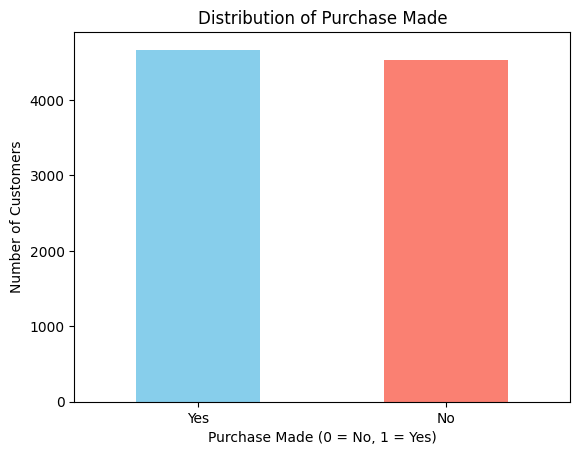

Purchase = Yes: 4667 customers (50.76%)
Purchase = No: 4528 customers (49.24%)


In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("sales_satisfaction.csv")

# Plot bar chart for 'Purchase_Made'
purchase_counts = df['Purchase_Made'].value_counts()
purchase_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Distribution of Purchase Made")
plt.xlabel("Purchase Made (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

# Print exact numbers and percentage
total = purchase_counts.sum()
for label, count in purchase_counts.items():
    percentage = (count / total) * 100
    print(f"Purchase = {label}: {count} customers ({percentage:.2f}%)")

